In [1]:
# Cell 1 — Load and harmonize finalized 60-s Processed window-level results
from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-ntsa-external-validation')

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats


def locate_phase1(start: Path) -> Path:
    marker = Path('results/rqa/rqa_window_level.csv')
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / marker).is_file():
            return candidate
        nested = candidate / 'phase1'
        if (nested / marker).is_file():
            return nested
    raise FileNotFoundError('Could not locate phase1.')


def require(condition: bool, message: str) -> None:
    if not condition:
        raise ValueError(message)


def normalize_session(series: pd.Series) -> pd.Series:
    extracted = series.astype(str).str.strip().str.extract(r'(\d+)(?:\D*)$', expand=False)
    require(extracted.notna().all(), 'Unrecognized session identifier.')
    return pd.to_numeric(extracted, errors='raise').astype(int)


def strict_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    values = series.astype(str).str.strip().str.casefold()
    truthy = {'true', '1', '1.0', 'yes', 'pass', 'included'}
    falsy = {'false', '0', '0.0', 'no', 'fail', 'excluded'}
    require(values.isin(truthy | falsy).all(), f'Invalid Boolean values in {series.name}.')
    return values.isin(truthy)


PHASE1_DIR = locate_phase1(Path.cwd())
WINDOW_SIZE_S = 60
REPRESENTATION = 'processed'
STATES = ('Awake', 'Drowsy')
METRICS = ('Mean_CC', 'Mean_NRMSE', 'DET', 'LLE')
EXPECTED_SESSIONS = 20
LLE_R2_THRESHOLD = 0.90
STATE_COLORS = {'Awake': '#2166ac', 'Drowsy': '#b2182b'}
METRIC_LABELS = {'Mean_CC': 'Mean CC', 'Mean_NRMSE': 'Mean NRMSE', 'DET': 'DET', 'LLE': r'LLE (s$^{-1}$)'}

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
if 'Times New Roman' in available_fonts:
    ACTIVE_FONT = 'Times New Roman'
else:
    ACTIVE_FONT = 'Liberation Serif' if 'Liberation Serif' in available_fonts else 'DejaVu Serif'
mpl.rcParams.update({
    'font.family': ACTIVE_FONT, 'font.size': 10.5, 'axes.labelsize': 11,
    'axes.titlesize': 11, 'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.9,
    'xtick.direction': 'out', 'ytick.direction': 'out', 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'savefig.transparent': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none',
})

# Cohort and temporal metadata.
index_path = PHASE1_DIR / 'segmentated_data/dhdata/segments_index.csv'
segment_index = pd.read_csv(index_path)
index_required = {'npz_file', 'window_id', 'window_size_s', 'label', 'start_time', 'stationarity_pass_processed'}
require(index_required.issubset(segment_index.columns), 'Segment index schema is incomplete.')
segment_index['stationarity_pass_processed'] = strict_bool(segment_index['stationarity_pass_processed'])
segment_index['session'] = normalize_session(segment_index['npz_file'])
segment_index['state'] = segment_index['label'].map({0: 'Awake', 1: 'Drowsy'})
base = segment_index.loc[segment_index['window_size_s'].eq(WINDOW_SIZE_S) & segment_index['stationarity_pass_processed'], ['session', 'state', 'window_id', 'start_time']].copy()
require(base['state'].isin(STATES).all(), 'Unexpected state in the primary cohort.')
require(not base.duplicated(['session', 'state', 'window_id']).any(), 'Duplicate primary cohort windows.')
base = base.sort_values(['session', 'state', 'start_time']).reset_index(drop=True)
base['window_order'] = base.groupby(['session', 'state']).cumcount() + 1

# Window-level Simplex originals are retained in the finalized PPS result files;
# only CC_original/NRMSE_original are used here, never surrogate estimates/tests.
simplex_paths = sorted((PHASE1_DIR / 'results/statistic/processed').glob('session_*_processed_pps_window_results.csv'))
require(len(simplex_paths) == EXPECTED_SESSIONS, f'Expected 20 window-level prediction files; found {len(simplex_paths)}.')
simplex = pd.concat([pd.read_csv(path) for path in simplex_paths], ignore_index=True)
simplex_required = {'session', 'representation', 'state', 'window_size', 'window_id', 'm', 'tau_seconds', 'n_horizons', 'hmax_seconds', 'theiler_seconds', 'CC_original', 'NRMSE_original'}
require(simplex_required.issubset(simplex.columns), 'Window-level prediction schema is incomplete.')
simplex = simplex.loc[simplex['representation'].astype(str).str.casefold().eq(REPRESENTATION) & simplex['window_size'].eq(WINDOW_SIZE_S), list(simplex_required)].copy()
simplex['session'] = normalize_session(simplex['session'])
require(not simplex.duplicated(['session', 'state', 'window_id']).any(), 'Duplicate prediction windows.')
require(np.allclose(simplex['m'], 8) and np.allclose(simplex['tau_seconds'], 0.16), 'Prediction reconstruction config changed.')
require(simplex['n_horizons'].eq(18).all() and np.allclose(simplex['hmax_seconds'], 4.0) and np.allclose(simplex['theiler_seconds'], 1.0), 'Prediction horizon/Theiler config changed.')
simplex = simplex.rename(columns={'CC_original': 'Mean_CC', 'NRMSE_original': 'Mean_NRMSE'})[['session', 'state', 'window_id', 'Mean_CC', 'Mean_NRMSE']]

rqa_path = PHASE1_DIR / 'results/rqa/rqa_window_level.csv'
rqa = pd.read_csv(rqa_path)
rqa_required = {'session', 'representation', 'state', 'window_size', 'window_id', 'target_rr', 'DET'}
require(rqa_required.issubset(rqa.columns), 'RQA schema is incomplete.')
rqa = rqa.loc[rqa['representation'].astype(str).str.casefold().eq(REPRESENTATION) & rqa['window_size'].eq(WINDOW_SIZE_S), list(rqa_required)].copy()
rqa['session'] = normalize_session(rqa['session'])
require(not rqa.duplicated(['session', 'state', 'window_id']).any(), 'Duplicate RQA windows.')
require(np.allclose(rqa['target_rr'], 0.02) and np.isfinite(rqa['DET']).all(), 'RQA config/output validation failed.')
rqa = rqa[['session', 'state', 'window_id', 'DET']]

lle_paths = sorted((PHASE1_DIR / 'results/lle/processed').glob('session_*_processed_rosenstein_lle.csv'))
require(len(lle_paths) == EXPECTED_SESSIONS, f'Expected 20 LLE files; found {len(lle_paths)}.')
lle = pd.concat([pd.read_csv(path) for path in lle_paths], ignore_index=True)
lle_required = {'session', 'state', 'window_size_s', 'window_id', 'representation', 'm', 'tau_s', 'fit_start_s', 'fit_end_s', 'lle_1_per_s', 'fit_r2', 'analysis_included', 'signal_finite', 'valid', 'qc_reason'}
require(lle_required.issubset(lle.columns), 'LLE schema is incomplete.')
lle = lle.loc[lle['representation'].astype(str).str.casefold().eq(REPRESENTATION) & lle['window_size_s'].eq(WINDOW_SIZE_S), list(lle_required)].copy()
lle['session'] = normalize_session(lle['session'])
require(not lle.duplicated(['session', 'state', 'window_id']).any(), 'Duplicate LLE windows.')
require(np.allclose(lle['m'], 8) and np.allclose(lle['tau_s'], 0.16), 'LLE reconstruction config changed.')
require(np.allclose(lle['fit_start_s'], 0.80) and np.allclose(lle['fit_end_s'], 1.30), 'LLE fit interval changed.')
lle_finite = np.isfinite(lle[['lle_1_per_s', 'fit_r2']].to_numpy(float)).all(axis=1)
lle_primary_valid = strict_bool(lle['analysis_included']) & strict_bool(lle['signal_finite']) & lle_finite & lle['fit_r2'].ge(LLE_R2_THRESHOLD)
require(strict_bool(lle['valid']).eq(lle_primary_valid).all(), 'Saved LLE validity differs from primary R2 >= 0.90 QC.')
lle['LLE_raw'] = lle['lle_1_per_s']
lle['LLE_valid'] = lle_primary_valid
lle['LLE'] = lle['LLE_raw'].where(lle['LLE_valid'])
lle = lle[['session', 'state', 'window_id', 'LLE', 'LLE_raw', 'fit_r2', 'LLE_valid', 'qc_reason']]

window_results = base.merge(simplex, on=['session', 'state', 'window_id'], how='left', validate='one_to_one').merge(rqa, on=['session', 'state', 'window_id'], how='left', validate='one_to_one').merge(lle, on=['session', 'state', 'window_id'], how='left', validate='one_to_one')
require(len(window_results) == len(base), 'Merged row count differs from the primary cohort.')
require(not window_results.duplicated(['session', 'state', 'window_id']).any(), 'Merged output is not one row per window.')
require(window_results['session'].nunique() == EXPECTED_SESSIONS, 'Expected 20 sessions after merge.')
require(set(window_results['state'].unique()) == set(STATES), 'Merged states are not Awake/Drowsy.')
require(window_results[['Mean_CC', 'Mean_NRMSE', 'DET']].notna().all().all(), 'Prediction/RQA merge has missing values.')

missingness = pd.DataFrame({'metric': METRICS, 'valid_windows': [int(window_results[metric].notna().sum()) for metric in METRICS], 'missing_or_invalid_windows': [int(window_results[metric].isna().sum()) for metric in METRICS]})
valid_counts = window_results.melt(id_vars=['session', 'state', 'window_id'], value_vars=METRICS, var_name='metric', value_name='value').groupby(['session', 'state', 'metric'])['value'].count().unstack(['state', 'metric']).reindex(columns=pd.MultiIndex.from_product([STATES, METRICS], names=['state', 'metric']))
dataset_summary = pd.DataFrame({'quantity': ['sessions', 'windows', 'Awake windows', 'Drowsy windows', 'chronological metadata'], 'value': [window_results['session'].nunique(), len(window_results), window_results['state'].eq('Awake').sum(), window_results['state'].eq('Drowsy').sum(), 'start_time + within-state order']})
display(dataset_summary, missingness, valid_counts)
print(f'Validation: PASS | 60-s Processed PPG | font={ACTIVE_FONT}')
print('No NTSA algorithm was rerun; no output file was written.')

,quantity,value
0,sessions,20
1,windows,901
2,Awake windows,596
3,Drowsy windows,305
4,chronological metadata,start_time + within-state order


,metric,valid_windows,missing_or_invalid_windows
0,Mean_CC,901,0
1,Mean_NRMSE,901,0
2,DET,901,0
3,LLE,872,29


state     Awake                     Drowsy                   
metric  Mean_CC Mean_NRMSE DET LLE Mean_CC Mean_NRMSE DET LLE
session                                                      
1            24         24  24  24       7          7   7   7
4            29         29  29  29      17         17  17  17
5            33         33  33  33      16         16  16  16
6            31         31  31  30      17         17  17  17
7            34         34  34  34      11         11  11  10
8            36         36  36  36      10         10  10  10
9            47         47  47  40      18         18  18  17
10           27         27  27  27       9          9   9   9
11           20         20  20  19      18         18  18  18
12           20         20  20  20      35         35  35  33
13           25         25  25  25      23         23  23  23
14           31         31  31  26      17         17  17  14
15           28         28  28  28       6          6   6   6
17           28         28  28  28      14         14  14  14
18           19         19  19  18      21         21  21  20
19           34         34  34  33      10         10  10  10
21           25         25  25  24      15         15  15  13
22           29         29  29  29      13         13  13  12
23           49         49  49  49      13         13  13  13
25           27         27  27  27      15         15  15  14

Validation: PASS | 60-s Processed PPG | font=Liberation Serif
No NTSA algorithm was rerun; no output file was written.


In [2]:
# Cell 2 — Within-state variability versus paired between-state shift
def finite_values(series: pd.Series) -> np.ndarray:
    values = pd.to_numeric(series, errors='coerce').to_numpy(float)
    return values[np.isfinite(values)]


def median_absolute_deviation(series: pd.Series) -> float:
    values = finite_values(series)
    return float(np.median(np.abs(values - np.median(values)))) if len(values) else np.nan


window_long = window_results.melt(id_vars=['session', 'state', 'window_id', 'window_order', 'start_time'], value_vars=METRICS, var_name='metric', value_name='value')
state_statistics = window_long.groupby(['metric', 'session', 'state'], observed=True)['value'].agg(n_valid='count', median='median', q25=lambda values: values.quantile(0.25), q75=lambda values: values.quantile(0.75), MAD=median_absolute_deviation).reset_index()
state_statistics['IQR'] = state_statistics['q75'] - state_statistics['q25']
require(state_statistics['n_valid'].ge(2).all(), 'A session-state-metric group has fewer than two valid windows.')

awake_stats = state_statistics.loc[state_statistics['state'].eq('Awake')].drop(columns='state').rename(columns={column: f'{column}_Awake' for column in ['n_valid', 'median', 'q25', 'q75', 'MAD', 'IQR']})
drowsy_stats = state_statistics.loc[state_statistics['state'].eq('Drowsy')].drop(columns='state').rename(columns={column: f'{column}_Drowsy' for column in ['n_valid', 'median', 'q25', 'q75', 'MAD', 'IQR']})
session_variability = awake_stats.merge(drowsy_stats, on=['metric', 'session'], validate='one_to_one')
session_variability['Delta_state'] = session_variability['median_Drowsy'] - session_variability['median_Awake']
session_variability['Abs_state_shift'] = session_variability['Delta_state'].abs()
session_variability['Within_MAD'] = 0.5 * (session_variability['MAD_Awake'] + session_variability['MAD_Drowsy'])
session_variability['Shift_to_variability_ratio'] = np.divide(session_variability['Abs_state_shift'], session_variability['Within_MAD'], out=np.full(len(session_variability), np.nan), where=session_variability['Within_MAD'].to_numpy(float) > 0)
require(not session_variability.duplicated(['metric', 'session']).any(), 'Duplicate session variability rows.')
require(session_variability.groupby('metric')['session'].nunique().eq(EXPECTED_SESSIONS).all(), 'Incomplete paired session coverage.')

variability_rows = []
for metric in METRICS:
    group = session_variability.loc[session_variability['metric'].eq(metric)]
    variability_rows.append({
        'Metric': metric, 'n_sessions': len(group),
        'Median_Awake_MAD': float(group['MAD_Awake'].median()),
        'Median_Drowsy_MAD': float(group['MAD_Drowsy'].median()),
        'Median_Awake_IQR': float(group['IQR_Awake'].median()),
        'Median_Drowsy_IQR': float(group['IQR_Drowsy'].median()),
        'Median_abs_state_shift': float(group['Abs_state_shift'].median()),
        'Median_shift_to_variability_ratio': float(group['Shift_to_variability_ratio'].median()),
        'Sessions_shift_gt_within_MAD': int((group['Abs_state_shift'] > group['Within_MAD']).sum()),
        'Sessions_shift_gt_2x_within_MAD': int((group['Abs_state_shift'] > 2 * group['Within_MAD']).sum()),
    })
variability_summary = pd.DataFrame(variability_rows)
display(variability_summary)
display(session_variability[['metric', 'session', 'MAD_Awake', 'MAD_Drowsy', 'Within_MAD', 'Abs_state_shift', 'Shift_to_variability_ratio']])
print('Ratios are descriptive only; windows were not treated as independent inferential samples.')

,Metric,n_sessions,Median_Awake_MAD,Median_Drowsy_MAD,Median_Awake_IQR,Median_Drowsy_IQR,Median_abs_state_shift,Median_shift_to_variability_ratio,Sessions_shift_gt_within_MAD,Sessions_shift_gt_2x_within_MAD
0,Mean_CC,20,0.042097,0.044900,0.083000,0.089720,0.036559,0.885211,10,1
1,Mean_NRMSE,20,0.037494,0.032550,0.071504,0.061240,0.034972,1.077177,11,2
2,DET,20,0.021692,0.020324,0.043642,0.045100,0.030555,1.172176,11,4
3,LLE,20,0.048798,0.044783,0.091318,0.078784,0.040975,0.861685,9,1


,metric,session,MAD_Awake,MAD_Drowsy,Within_MAD,Abs_state_shift,Shift_to_variability_ratio
0,DET,1,0.008725,0.007436,0.008081,0.019922,2.465306
1,DET,4,0.019197,0.013486,0.016341,0.018477,1.130690
2,DET,5,0.032874,0.020372,0.026623,0.022460,0.843623
3,DET,6,0.024716,0.021788,0.023252,0.014829,0.637771
4,DET,7,0.022028,0.020636,0.021332,0.040265,1.887514
...,...,...,...,...,...,...,...
75,Mean_NRMSE,19,0.034079,0.027464,0.030771,0.059709,1.940405
76,Mean_NRMSE,21,0.024492,0.036112,0.030302,0.006387,0.210771
77,Mean_NRMSE,22,0.038541,0.031540,0.035041,0.080391,2.294225
78,Mean_NRMSE,23,0.028226,0.057653,0.042940,0.000488,0.011364


Ratios are descriptive only; windows were not treated as independent inferential samples.


,metric,state,n_sessions,median_slope,q25_slope,q75_slope,n_positive,n_negative,n_approximately_zero,slope_IQR
0,DET,Awake,20,-0.016030,-0.035549,0.003774,7,13,0,0.039323
1,DET,Drowsy,20,0.020561,-0.016985,0.041360,13,7,0,0.058345
2,LLE,Awake,20,-0.020136,-0.035019,0.010046,8,12,0,0.045065
3,LLE,Drowsy,20,-0.005969,-0.052195,0.028640,10,10,0,0.080835
4,Mean_CC,Awake,20,-0.036505,-0.067600,0.007230,6,14,0,0.074830
5,Mean_CC,Drowsy,20,0.048730,-0.016654,0.068514,13,7,0,0.085167
6,Mean_NRMSE,Awake,20,0.038545,0.001736,0.067344,16,4,0,0.065607
7,Mean_NRMSE,Drowsy,20,-0.027535,-0.044627,0.013552,8,12,0,0.058179


,Metric,Median_Drowsy_minus_Awake_MAD,Sessions_Drowsy_MAD_gt_Awake,Median_Drowsy_minus_Awake_IQR,Sessions_Drowsy_IQR_gt_Awake,Sessions_Drowsy_abs_slope_gt_Awake
0,Mean_CC,0.008619,12,0.006692,12,10
1,Mean_NRMSE,-0.006755,9,-0.012152,6,10
2,DET,-0.002160,7,-0.003065,9,12
3,LLE,-0.009006,7,-0.016694,8,12


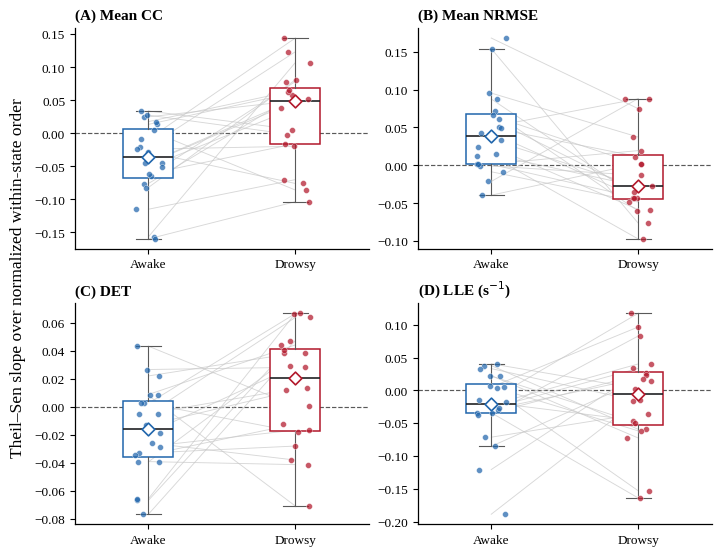

Figure is inline only; no file was saved. Open diamonds show across-session medians.


In [3]:
# Cell 3 — Within-state temporal structure using Theil–Sen slopes
SLOPE_ZERO_ATOL = 1e-12
slope_rows = []
for (metric, session, state), group in window_long.groupby(['metric', 'session', 'state'], observed=True):
    ordered = group.loc[np.isfinite(group['value'])].sort_values(['start_time', 'window_order'])
    n_windows = len(ordered)
    if n_windows < 2:
        slope = np.nan
    else:
        normalized_order = np.linspace(0.0, 1.0, n_windows)
        slope = float(stats.theilslopes(ordered['value'].to_numpy(float), normalized_order).slope)
    slope_rows.append({'metric': metric, 'session': int(session), 'state': state, 'n_windows': n_windows, 'theil_sen_slope': slope})
temporal_slopes = pd.DataFrame(slope_rows)
require(np.isfinite(temporal_slopes['theil_sen_slope']).all(), 'A temporal slope could not be estimated.')
require(temporal_slopes.groupby(['metric', 'state'])['session'].nunique().eq(EXPECTED_SESSIONS).all(), 'Incomplete temporal-slope coverage.')

slope_summary = temporal_slopes.groupby(['metric', 'state'], observed=True)['theil_sen_slope'].agg(n_sessions='size', median_slope='median', q25_slope=lambda values: values.quantile(0.25), q75_slope=lambda values: values.quantile(0.75), n_positive=lambda values: int((values > SLOPE_ZERO_ATOL).sum()), n_negative=lambda values: int((values < -SLOPE_ZERO_ATOL).sum()), n_approximately_zero=lambda values: int(np.isclose(values, 0.0, atol=SLOPE_ZERO_ATOL, rtol=0.0).sum())).reset_index()
slope_summary['slope_IQR'] = slope_summary['q75_slope'] - slope_summary['q25_slope']

variability_comparison_rows = []
for metric in METRICS:
    variability = session_variability.loc[session_variability['metric'].eq(metric)]
    slope_matrix = temporal_slopes.loc[temporal_slopes['metric'].eq(metric)].pivot(index='session', columns='state', values='theil_sen_slope').reindex(columns=STATES)
    variability_comparison_rows.append({
        'Metric': metric,
        'Median_Drowsy_minus_Awake_MAD': float((variability['MAD_Drowsy'] - variability['MAD_Awake']).median()),
        'Sessions_Drowsy_MAD_gt_Awake': int((variability['MAD_Drowsy'] > variability['MAD_Awake']).sum()),
        'Median_Drowsy_minus_Awake_IQR': float((variability['IQR_Drowsy'] - variability['IQR_Awake']).median()),
        'Sessions_Drowsy_IQR_gt_Awake': int((variability['IQR_Drowsy'] > variability['IQR_Awake']).sum()),
        'Sessions_Drowsy_abs_slope_gt_Awake': int((slope_matrix['Drowsy'].abs() > slope_matrix['Awake'].abs()).sum()),
    })
variability_comparison = pd.DataFrame(variability_comparison_rows)
display(slope_summary, variability_comparison)

# Inline-only publication figure: paired session slope distributions.
rng = np.random.default_rng(20260903)
fig, axes = plt.subplots(2, 2, figsize=(7.10, 5.45), constrained_layout=True)
for panel_index, (axis, metric) in enumerate(zip(axes.flat, METRICS)):
    metric_data = temporal_slopes.loc[temporal_slopes['metric'].eq(metric)]
    paired = metric_data.pivot(index='session', columns='state', values='theil_sen_slope').reindex(columns=STATES)
    for _, row in paired.iterrows():
        axis.plot([0, 1], row.to_numpy(float), color='0.78', linewidth=0.65, alpha=0.70, zorder=1)
    arrays = [paired[state].to_numpy(float) for state in STATES]
    boxes = axis.boxplot(arrays, positions=[0, 1], widths=0.34, patch_artist=True, showfliers=False, whis=1.5, zorder=2)
    for patch, state in zip(boxes['boxes'], STATES):
        patch.set_facecolor('white'); patch.set_edgecolor(STATE_COLORS[state]); patch.set_linewidth(1.1)
    for median in boxes['medians']:
        median.set_color('#202124'); median.set_linewidth(1.2)
    for artist in (*boxes['whiskers'], *boxes['caps']):
        artist.set_color('0.35'); artist.set_linewidth(0.8)
    for position, state, values in zip([0, 1], STATES, arrays):
        jitter = rng.uniform(-0.10, 0.10, size=len(values))
        axis.scatter(position + jitter, values, s=18, color=STATE_COLORS[state], alpha=0.72, edgecolors='white', linewidths=0.35, zorder=3)
        axis.scatter(position, np.median(values), marker='D', s=42, facecolors='white', edgecolors=STATE_COLORS[state], linewidths=1.2, zorder=4)
    axis.axhline(0.0, color='0.35', linestyle='--', linewidth=0.85, zorder=0)
    axis.set_xticks([0, 1], STATES)
    axis.set_title(f"({'ABCD'[panel_index]}) {METRIC_LABELS[metric]}", loc='left', fontweight='bold')
    axis.margins(x=0.25)
fig.supylabel('Theil–Sen slope over normalized within-state order')
plt.show()
print('Figure is inline only; no file was saved. Open diamonds show across-session medians.')

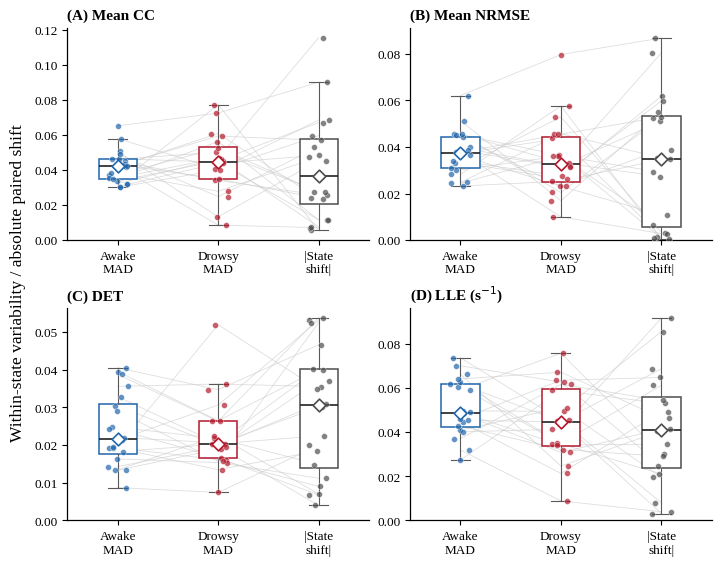

,Metric,Median Awake MAD,Median Drowsy MAD,Median |State shift|,Shift > within MAD,Shift > 2× within MAD,Median shift/variability ratio,Median temporal slope Awake,Median temporal slope Drowsy,Drowsy MAD > Awake
0,Mean_CC,0.0421,0.0449,0.0366,10/20,1/20,0.8852,-0.0365,0.0487,12/20
1,Mean_NRMSE,0.0375,0.0326,0.0350,11/20,2/20,1.0772,0.0385,-0.0275,9/20
2,DET,0.0217,0.0203,0.0306,11/20,4/20,1.1722,-0.0160,0.0206,7/20
3,LLE,0.0488,0.0448,0.0410,9/20,1/20,0.8617,-0.0201,-0.0060,7/20


## Exploratory within-state validation

Window-level observations were used only to characterize within-session structure; the session remained the scientific unit.

- Mean_CC: median |state shift|=0.0366; median shift/within-MAD ratio=0.885; shift exceeded pooled within-state MAD in 10/20 sessions; Drowsy MAD exceeded Awake MAD in 12/20 sessions.
- Mean_NRMSE: median |state shift|=0.0350; median shift/within-MAD ratio=1.077; shift exceeded pooled within-state MAD in 11/20 sessions; Drowsy MAD exceeded Awake MAD in 9/20 sessions.
- DET: median |state shift|=0.0306; median shift/within-MAD ratio=1.172; shift exceeded pooled within-state MAD in 11/20 sessions; Drowsy MAD exceeded Awake MAD in 7/20 sessions.
- LLE: median |state shift|=0.0410; median shift/within-MAD ratio=0.862; shift exceeded pooled within-state MAD in 9/20 sessions; Drowsy MAD exceeded Awake MAD in 7/20 sessions.

The temporal slopes are descriptive summaries of ordered windows within each labeled state; they do not by themselves establish transition dynamics.
No hypothesis tests, multiplicity correction, or new primary claims were introduced.

Both figures and all tables are inline only; nothing was saved to disk.


In [4]:
# Cell 4 — Integrated variability/shift figure, compact evidence table, and cautious conclusion
CATEGORY_ORDER = ('Awake MAD', 'Drowsy MAD', '|State shift|')
CATEGORY_COLORS = {'Awake MAD': '#2166ac', 'Drowsy MAD': '#b2182b', '|State shift|': '#4d4d4d'}
plot_rows = []
for row in session_variability.itertuples(index=False):
    plot_rows.extend([
        {'metric': row.metric, 'session': row.session, 'category': 'Awake MAD', 'value': row.MAD_Awake},
        {'metric': row.metric, 'session': row.session, 'category': 'Drowsy MAD', 'value': row.MAD_Drowsy},
        {'metric': row.metric, 'session': row.session, 'category': '|State shift|', 'value': row.Abs_state_shift},
    ])
variability_plot = pd.DataFrame(plot_rows)
rng = np.random.default_rng(20260904)
fig, axes = plt.subplots(2, 2, figsize=(7.10, 5.55), constrained_layout=True)
for panel_index, (axis, metric) in enumerate(zip(axes.flat, METRICS)):
    metric_data = variability_plot.loc[variability_plot['metric'].eq(metric)]
    paired = metric_data.pivot(index='session', columns='category', values='value').reindex(columns=CATEGORY_ORDER)
    positions = np.arange(len(CATEGORY_ORDER))
    for _, row in paired.iterrows():
        axis.plot(positions, row.to_numpy(float), color='0.80', linewidth=0.60, alpha=0.65, zorder=1)
    arrays = [paired[category].to_numpy(float) for category in CATEGORY_ORDER]
    boxes = axis.boxplot(arrays, positions=positions, widths=0.38, patch_artist=True, showfliers=False, whis=1.5, zorder=2)
    for patch, category in zip(boxes['boxes'], CATEGORY_ORDER):
        patch.set_facecolor('white'); patch.set_edgecolor(CATEGORY_COLORS[category]); patch.set_linewidth(1.1)
    for median in boxes['medians']:
        median.set_color('#202124'); median.set_linewidth(1.2)
    for artist in (*boxes['whiskers'], *boxes['caps']):
        artist.set_color('0.35'); artist.set_linewidth(0.8)
    for position, category, values in zip(positions, CATEGORY_ORDER, arrays):
        jitter = rng.uniform(-0.10, 0.10, size=len(values))
        axis.scatter(position + jitter, values, s=18, color=CATEGORY_COLORS[category], alpha=0.70, edgecolors='white', linewidths=0.35, zorder=3)
        axis.scatter(position, np.median(values), marker='D', s=42, facecolors='white', edgecolors=CATEGORY_COLORS[category], linewidths=1.2, zorder=4)
    axis.set_xticks(positions, ['Awake\nMAD', 'Drowsy\nMAD', '|State\nshift|'])
    axis.set_ylim(bottom=0)
    axis.set_title(f"({'ABCD'[panel_index]}) {METRIC_LABELS[metric]}", loc='left', fontweight='bold')
    axis.margins(x=0.16)
fig.supylabel('Within-state variability / absolute paired shift')
plt.show()

integrated_rows = []
for metric in METRICS:
    variability = variability_summary.loc[variability_summary['Metric'].eq(metric)].iloc[0]
    slopes = slope_summary.loc[slope_summary['metric'].eq(metric)].set_index('state')
    comparison = variability_comparison.loc[variability_comparison['Metric'].eq(metric)].iloc[0]
    integrated_rows.append({
        'Metric': metric,
        'Median Awake MAD': variability['Median_Awake_MAD'],
        'Median Drowsy MAD': variability['Median_Drowsy_MAD'],
        'Median |State shift|': variability['Median_abs_state_shift'],
        'Shift > within MAD': f"{int(variability['Sessions_shift_gt_within_MAD'])}/{int(variability['n_sessions'])}",
        'Shift > 2× within MAD': f"{int(variability['Sessions_shift_gt_2x_within_MAD'])}/{int(variability['n_sessions'])}",
        'Median shift/variability ratio': variability['Median_shift_to_variability_ratio'],
        'Median temporal slope Awake': slopes.loc['Awake', 'median_slope'],
        'Median temporal slope Drowsy': slopes.loc['Drowsy', 'median_slope'],
        'Drowsy MAD > Awake': f"{int(comparison['Sessions_Drowsy_MAD_gt_Awake'])}/{EXPECTED_SESSIONS}",
    })
integrated_table = pd.DataFrame(integrated_rows)
display(integrated_table.style.format({column: '{:.4f}' for column in integrated_table.columns if column.startswith('Median')}))

conclusion_lines = ['## Exploratory within-state validation', '', 'Window-level observations were used only to characterize within-session structure; the session remained the scientific unit.', '']
for _, row in integrated_table.iterrows():
    conclusion_lines.append(
        f"- {row['Metric']}: median |state shift|={row['Median |State shift|']:.4f}; "
        f"median shift/within-MAD ratio={row['Median shift/variability ratio']:.3f}; "
        f"shift exceeded pooled within-state MAD in {row['Shift > within MAD']} sessions; "
        f"Drowsy MAD exceeded Awake MAD in {row['Drowsy MAD > Awake']} sessions."
    )
conclusion_lines.extend(['', 'The temporal slopes are descriptive summaries of ordered windows within each labeled state; they do not by themselves establish transition dynamics.', 'No hypothesis tests, multiplicity correction, or new primary claims were introduced.'])
conclusion = '\n'.join(conclusion_lines)
display(Markdown(conclusion))
print('Both figures and all tables are inline only; nothing was saved to disk.')

,session,n_windows,Awake_windows,Drowsy_windows,Awake_to_Drowsy_boundaries,first_Drowsy_normalized_time
0,1,31,24,7,4,0.499409
1,4,46,29,17,2,0.239680
2,5,49,33,16,3,0.452570
3,6,48,31,17,2,0.276069
4,7,45,34,11,2,0.348413
5,8,46,36,10,2,0.631290
6,9,65,47,18,2,0.389910
7,10,36,27,9,2,0.250878
8,11,38,20,18,2,0.248889
9,12,55,20,35,3,0.176622


Alignment rule: the first Drowsy window following Awake is relative index 0. Observed Awake-to-Drowsy boundaries/session: 2–4.


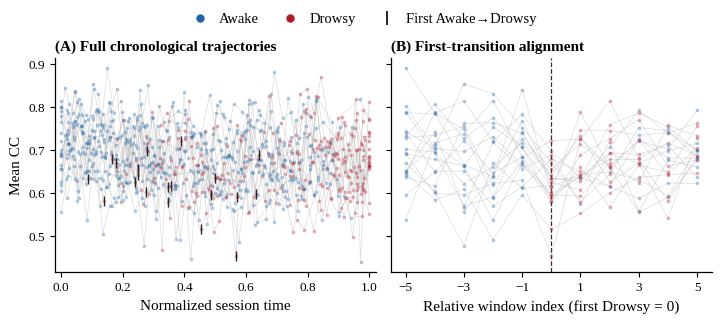

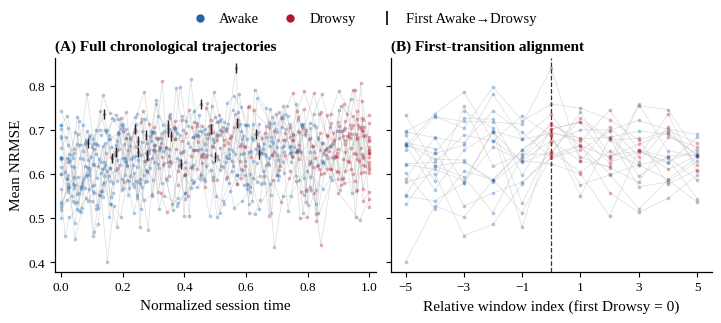

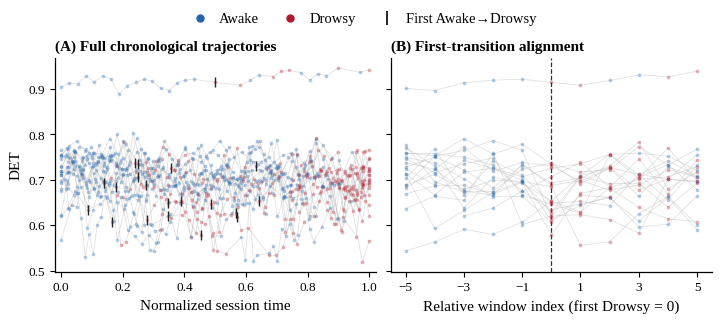

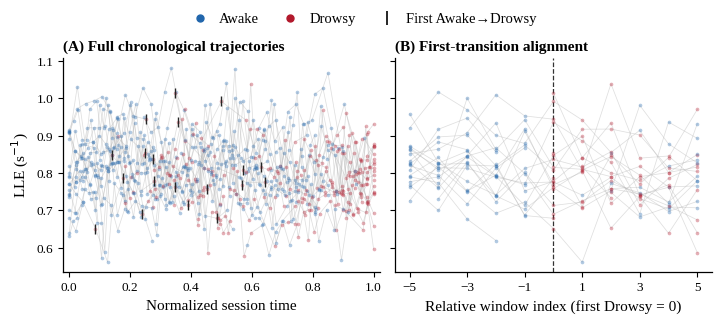

Four trajectory figures are inline only; lines are unsmoothed and missing metric values were not imputed.


In [5]:
# Cell 5 — Chronological and first-transition-aligned session trajectories
RELATIVE_WINDOW_LIMIT = 5

def first_awake_to_drowsy_boundary(states: pd.Series) -> tuple[int | None, int]:
    labels = states.astype(str).to_numpy()
    transitions = np.flatnonzero((labels[:-1] == 'Awake') & (labels[1:] == 'Drowsy')) + 1
    return (int(transitions[0]), int(len(transitions))) if len(transitions) else (None, 0)

trajectory_groups = []
boundary_rows = []
for session, group in window_results.groupby('session', sort=True):
    ordered = group.sort_values(['start_time', 'window_id']).reset_index(drop=True).copy()
    elapsed = ordered['start_time'].to_numpy(float) - float(ordered['start_time'].min())
    span = float(elapsed.max()) if len(elapsed) else 0.0
    ordered['normalized_session_time'] = elapsed / span if span > 0 else np.linspace(0.0, 1.0, len(ordered))
    boundary_position, n_boundaries = first_awake_to_drowsy_boundary(ordered['state'])
    ordered['relative_window'] = np.arange(len(ordered), dtype=int) - boundary_position if boundary_position is not None else np.nan
    ordered['first_transition_position'] = boundary_position
    trajectory_groups.append(ordered)
    boundary_rows.append({
        'session': int(session), 'n_windows': len(ordered),
        'Awake_windows': int(ordered['state'].eq('Awake').sum()),
        'Drowsy_windows': int(ordered['state'].eq('Drowsy').sum()),
        'Awake_to_Drowsy_boundaries': n_boundaries,
        'first_Drowsy_normalized_time': float(ordered.loc[boundary_position, 'normalized_session_time']) if boundary_position is not None else np.nan,
    })
chronological_results = pd.concat(trajectory_groups, ignore_index=True)
transition_audit = pd.DataFrame(boundary_rows)
require(transition_audit['Awake_to_Drowsy_boundaries'].gt(0).all(), 'At least one session has no identifiable Awake-to-Drowsy boundary.')
display(transition_audit)
print(
    'Alignment rule: the first Drowsy window following Awake is relative index 0. '
    f"Observed Awake-to-Drowsy boundaries/session: {transition_audit['Awake_to_Drowsy_boundaries'].min()}–{transition_audit['Awake_to_Drowsy_boundaries'].max()}."
)

state_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markersize=5, color=STATE_COLORS[state], label=state)
    for state in STATES
] + [Line2D([0], [0], marker='|', linestyle='none', markersize=10, markeredgewidth=1.4, color='0.15', label='First Awake→Drowsy')]
for metric in METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(7.10, 3.15), constrained_layout=True, sharey=True)
    for session, ordered in chronological_results.groupby('session', sort=True):
        x_full = ordered['normalized_session_time'].to_numpy(float)
        y_full = ordered[metric].to_numpy(float)
        axes[0].plot(x_full, y_full, color='0.72', linewidth=0.55, alpha=0.45, zorder=1)
        for state in STATES:
            mask = ordered['state'].eq(state) & np.isfinite(ordered[metric])
            axes[0].scatter(ordered.loc[mask, 'normalized_session_time'], ordered.loc[mask, metric], s=7, color=STATE_COLORS[state], alpha=0.35, linewidths=0, zorder=2)
        boundary_position = int(ordered['first_transition_position'].iloc[0])
        boundary_value = ordered[metric].iloc[boundary_position]
        if np.isfinite(boundary_value):
            axes[0].scatter(ordered['normalized_session_time'].iloc[boundary_position], boundary_value, marker='|', s=55, color='0.15', linewidths=1.0, zorder=3)

        aligned = ordered.loc[ordered['relative_window'].between(-RELATIVE_WINDOW_LIMIT, RELATIVE_WINDOW_LIMIT)]
        axes[1].plot(aligned['relative_window'], aligned[metric], color='0.72', linewidth=0.55, alpha=0.45, zorder=1)
        for state in STATES:
            mask = aligned['state'].eq(state) & np.isfinite(aligned[metric])
            axes[1].scatter(aligned.loc[mask, 'relative_window'], aligned.loc[mask, metric], s=7, color=STATE_COLORS[state], alpha=0.35, linewidths=0, zorder=2)
    axes[0].set_title('(A) Full chronological trajectories', loc='left', fontweight='bold')
    axes[0].set_xlabel('Normalized session time')
    axes[0].set_ylabel(METRIC_LABELS[metric])
    axes[0].set_xlim(-0.02, 1.02)
    axes[1].axvline(0, color='0.20', linestyle='--', linewidth=0.9, zorder=0)
    axes[1].set_title('(B) First-transition alignment', loc='left', fontweight='bold')
    axes[1].set_xlabel('Relative window index (first Drowsy = 0)')
    axes[1].set_xticks(np.arange(-RELATIVE_WINDOW_LIMIT, RELATIVE_WINDOW_LIMIT + 1, 2))
    fig.legend(handles=state_handles, loc='outside upper center', ncol=3, frameon=False, handletextpad=0.35, columnspacing=1.1)
    plt.show()
print('Four trajectory figures are inline only; lines are unsmoothed and missing metric values were not imputed.')

In [6]:
# Cell 6 — Local transition effects and comparison with whole-state effects
K_DEFAULT = 3
K_SENSITIVITY = (2, 3, 5)
EXPECTED_DIRECTION = {'Mean_CC': -1, 'Mean_NRMSE': 1, 'DET': -1, 'LLE': -1}
EXPECTED_DIRECTION_LABEL = {'Mean_CC': '< 0', 'Mean_NRMSE': '> 0', 'DET': '< 0', 'LLE': '< 0'}

def compute_transition_effects(metric: str, k: int) -> pd.DataFrame:
    rows = []
    state_effect = session_variability.loc[session_variability['metric'].eq(metric)].set_index('session')['Delta_state']
    for session, ordered in chronological_results.groupby('session', sort=True):
        ordered = ordered.sort_values(['start_time', 'window_id']).reset_index(drop=True)
        boundary = int(ordered['first_transition_position'].iloc[0])
        pre = ordered.iloc[max(0, boundary - k):boundary]
        post = ordered.iloc[boundary:boundary + k]
        structurally_valid = (
            len(pre) == k and len(post) == k and
            pre['state'].eq('Awake').all() and post['state'].eq('Drowsy').all()
        )
        metrically_valid = structurally_valid and pre[metric].notna().all() and post[metric].notna().all()
        if not metrically_valid:
            continue
        delta_transition = float(post[metric].median() - pre[metric].median())
        delta_state = float(state_effect.loc[session])
        rows.append({
            'metric': metric, 'session': int(session), 'K': k,
            'Delta_transition': delta_transition, 'Delta_state': delta_state,
            'sign_agreement': bool(delta_transition * delta_state > 0),
            'expected_direction': bool(EXPECTED_DIRECTION[metric] * delta_transition > 0),
        })
    return pd.DataFrame(rows)

transition_effects = pd.concat(
    [compute_transition_effects(metric, k) for k in K_SENSITIVITY for metric in METRICS],
    ignore_index=True,
)
summary_rows = []
for (metric, k), group in transition_effects.groupby(['metric', 'K'], sort=False):
    rho = stats.spearmanr(group['Delta_transition'], group['Delta_state']).statistic if len(group) >= 3 and group[['Delta_transition', 'Delta_state']].nunique().min() > 1 else np.nan
    summary_rows.append({
        'Metric': metric, 'K': int(k), 'Valid sessions': len(group),
        'Median Delta_transition': float(group['Delta_transition'].median()),
        'Median Delta_state': float(group['Delta_state'].median()),
        'Sign agreement': f"{int(group['sign_agreement'].sum())}/{len(group)}",
        'Expected direction': EXPECTED_DIRECTION_LABEL[metric],
        'Sessions in expected direction': f"{int(group['expected_direction'].sum())}/{len(group)}",
        'Spearman rho': float(rho),
    })
transition_summary = pd.DataFrame(summary_rows).sort_values(['K', 'Metric'], key=lambda values: values.map({metric: index for index, metric in enumerate(METRICS)}) if values.name == 'Metric' else values).reset_index(drop=True)
transition_summary_k3 = transition_summary.loc[transition_summary['K'].eq(K_DEFAULT)].reset_index(drop=True)
display(transition_summary_k3.style.format({'Median Delta_transition': '{:.4f}', 'Median Delta_state': '{:.4f}', 'Spearman rho': '{:.3f}'}))
display(transition_summary.style.format({'Median Delta_transition': '{:.4f}', 'Median Delta_state': '{:.4f}', 'Spearman rho': '{:.3f}'}))
print('K=3 is the default local summary; K=2 and K=5 are descriptive sensitivity checks. Spearman p-values were intentionally not computed or reported.')

,Metric,K,Valid sessions,Median Delta_transition,Median Delta_state,Sign agreement,Expected direction,Sessions in expected direction,Spearman rho
0,Mean_CC,3,16,-0.0270,-0.0366,15/16,< 0,10/16,0.791
1,Mean_NRMSE,3,16,0.0137,0.0350,13/16,> 0,10/16,0.682
2,DET,3,16,-0.0180,-0.0186,11/16,< 0,11/16,0.482
3,LLE,3,11,-0.0367,-0.0406,7/11,< 0,7/11,0.327


,Metric,K,Valid sessions,Median Delta_transition,Median Delta_state,Sign agreement,Expected direction,Sessions in expected direction,Spearman rho
0,Mean_CC,2,18,-0.0405,-0.0366,13/18,< 0,13/18,0.292
1,Mean_NRMSE,2,18,0.0259,0.0350,8/18,> 0,10/18,0.377
2,DET,2,18,-0.0277,-0.0186,13/18,< 0,14/18,0.628
3,LLE,2,13,-0.0338,-0.0414,7/13,< 0,7/13,0.264
4,Mean_CC,3,16,-0.0270,-0.0366,15/16,< 0,10/16,0.791
5,Mean_NRMSE,3,16,0.0137,0.0350,13/16,> 0,10/16,0.682
6,DET,3,16,-0.0180,-0.0186,11/16,< 0,11/16,0.482
7,LLE,3,11,-0.0367,-0.0406,7/11,< 0,7/11,0.327
8,Mean_CC,5,9,-0.0323,-0.0276,7/9,< 0,6/9,0.817
9,Mean_NRMSE,5,9,0.0282,0.0291,6/9,> 0,7/9,0.733


K=3 is the default local summary; K=2 and K=5 are descriptive sensitivity checks. Spearman p-values were intentionally not computed or reported.


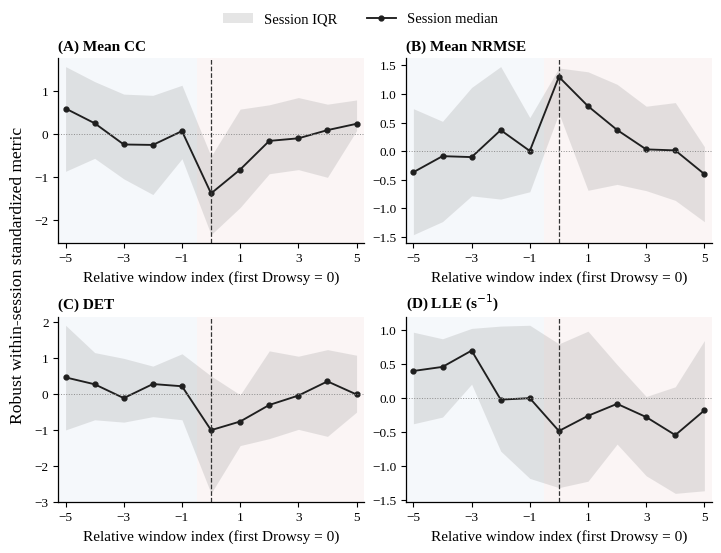

,Metric,Aggregate post-pre change,Expected direction,Direction agrees with RQ2,Lowest descriptive AIC,Median transition IQR,Clarity ratio,Min–max sessions/index,Step RMSE,Step AIC,Linear RMSE,Linear AIC,Piecewise linear RMSE,Piecewise linear AIC
0,Mean_CC,-0.199,< 0,True,Piecewise linear,1.791,0.111,19–20,0.472,-12.496,0.515,-10.592,0.278,-22.153
1,Mean_NRMSE,0.288,> 0,True,Piecewise linear,1.748,0.165,19–20,0.442,-13.974,0.480,-12.139,0.243,-25.165
2,DET,-0.444,< 0,True,Piecewise linear,1.869,0.238,19–20,0.365,-18.201,0.432,-14.471,0.300,-20.523
3,LLE,-0.670,< 0,True,Piecewise linear,1.571,0.427,18–20,0.223,-29.020,0.237,-27.670,0.196,-29.897


## Hypothesis-generating transition note

The clearest standardized transition-centered contrasts were LLE and DET when ranked by absolute aggregate change relative to the typical session IQR band. The widest typical transition IQR was observed for DET, indicating the greatest session heterogeneity on this descriptive scale.

Descriptive aggregate shape by lowest AIC: Mean_CC: boundary-anchored change in slope; Mean_NRMSE: boundary-anchored change in slope; DET: boundary-anchored change in slope; LLE: boundary-anchored change in slope. This comparison does not constitute model-selection inference. The aggregate post–pre direction agreed with the frozen RQ2 direction for 4/4 metrics.

For the strict K=3 local comparison, sessions in the frozen RQ2 direction were: Mean_CC 10/16; Mean_NRMSE 10/16; DET 11/16; LLE 7/11. Because every session contains repeated Awake/Drowsy blocks, alignment uses the first observed Awake-to-Drowsy boundary and must not be interpreted as a unique physiological transition. The session remains the primary unit; no hypothesis tests or manuscript-claim updates were made.

Aggregate transition figure and tables are inline only; no external file was written.


In [7]:
# Cell 7 — Robustly standardized aggregate transition shape and descriptive model comparison
standardized_rows = []
for metric in METRICS:
    for session, ordered in chronological_results.groupby('session', sort=True):
        values = finite_values(ordered[metric])
        session_median = float(np.median(values))
        session_mad = float(np.median(np.abs(values - session_median)))
        if not np.isfinite(session_mad) or session_mad <= 0:
            continue
        aligned = ordered.loc[ordered['relative_window'].between(-RELATIVE_WINDOW_LIMIT, RELATIVE_WINDOW_LIMIT), ['session', 'relative_window', metric]].copy()
        aligned['metric'] = metric
        aligned['z_robust'] = (aligned[metric] - session_median) / session_mad
        standardized_rows.append(aligned[['metric', 'session', 'relative_window', 'z_robust']])
standardized_transition = pd.concat(standardized_rows, ignore_index=True)
aggregate_transition = standardized_transition.groupby(['metric', 'relative_window'], observed=True)['z_robust'].agg(
    n_sessions='count', median_z='median',
    q25_z=lambda values: values.quantile(0.25),
    q75_z=lambda values: values.quantile(0.75),
).reset_index()
aggregate_transition['IQR_z'] = aggregate_transition['q75_z'] - aggregate_transition['q25_z']

def fit_descriptive_model(x: np.ndarray, y: np.ndarray, model: str) -> dict[str, float | str]:
    if model == 'Step':
        design = np.column_stack([np.ones_like(x), x >= 0]); parameters = 2
    elif model == 'Linear':
        design = np.column_stack([np.ones_like(x), x]); parameters = 2
    elif model == 'Piecewise linear':
        design = np.column_stack([np.ones_like(x), x, np.maximum(x, 0)]); parameters = 3
    else:
        raise ValueError(f'Unknown model: {model}')
    fitted = design @ np.linalg.lstsq(design, y, rcond=None)[0]
    residual = y - fitted
    rss = max(float(np.sum(residual ** 2)), np.finfo(float).tiny)
    return {'model': model, 'RMSE': float(np.sqrt(np.mean(residual ** 2))), 'AIC': float(len(y) * np.log(rss / len(y)) + 2 * parameters)}

shape_rows = []
for metric in METRICS:
    curve = aggregate_transition.loc[aggregate_transition['metric'].eq(metric)].sort_values('relative_window')
    x = curve['relative_window'].to_numpy(float)
    y = curve['median_z'].to_numpy(float)
    fits = [fit_descriptive_model(x, y, model) for model in ('Step', 'Linear', 'Piecewise linear')]
    best = min(fits, key=lambda result: result['AIC'])
    pre_median = float(curve.loc[curve['relative_window'].lt(0), 'median_z'].median())
    post_median = float(curve.loc[curve['relative_window'].ge(0), 'median_z'].median())
    aggregate_change = post_median - pre_median
    typical_iqr = float(curve['IQR_z'].median())
    result = {
        'Metric': metric, 'Aggregate post-pre change': aggregate_change,
        'Expected direction': EXPECTED_DIRECTION_LABEL[metric],
        'Direction agrees with RQ2': bool(EXPECTED_DIRECTION[metric] * aggregate_change > 0),
        'Lowest descriptive AIC': best['model'], 'Median transition IQR': typical_iqr,
        'Clarity ratio': abs(aggregate_change) / typical_iqr if typical_iqr > 0 else np.nan,
        'Min–max sessions/index': f"{int(curve['n_sessions'].min())}–{int(curve['n_sessions'].max())}",
    }
    for fit in fits:
        result[f"{fit['model']} RMSE"] = fit['RMSE']
        result[f"{fit['model']} AIC"] = fit['AIC']
    shape_rows.append(result)
transition_shape_summary = pd.DataFrame(shape_rows)

fig, axes = plt.subplots(2, 2, figsize=(7.10, 5.45), constrained_layout=True)
for panel_index, (axis, metric) in enumerate(zip(axes.flat, METRICS)):
    curve = aggregate_transition.loc[aggregate_transition['metric'].eq(metric)].sort_values('relative_window')
    x = curve['relative_window'].to_numpy(float)
    median_z = curve['median_z'].to_numpy(float)
    q25 = curve['q25_z'].to_numpy(float)
    q75 = curve['q75_z'].to_numpy(float)
    axis.axvspan(-RELATIVE_WINDOW_LIMIT - 0.5, -0.5, color=STATE_COLORS['Awake'], alpha=0.045, linewidth=0)
    axis.axvspan(-0.5, RELATIVE_WINDOW_LIMIT + 0.5, color=STATE_COLORS['Drowsy'], alpha=0.045, linewidth=0)
    axis.fill_between(x, q25, q75, color='0.55', alpha=0.22, linewidth=0, label='Session IQR')
    axis.plot(x, median_z, color='0.12', marker='o', markersize=3.5, linewidth=1.35, label='Session median')
    axis.axhline(0, color='0.55', linewidth=0.7, linestyle=':')
    axis.axvline(0, color='0.20', linewidth=0.9, linestyle='--')
    axis.set_xlim(-RELATIVE_WINDOW_LIMIT - 0.25, RELATIVE_WINDOW_LIMIT + 0.25)
    axis.set_xticks(np.arange(-RELATIVE_WINDOW_LIMIT, RELATIVE_WINDOW_LIMIT + 1, 2))
    axis.set_title(f"({'ABCD'[panel_index]}) {METRIC_LABELS[metric]}", loc='left', fontweight='bold')
    axis.set_xlabel('Relative window index (first Drowsy = 0)')
fig.supylabel('Robust within-session standardized metric')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper center', ncol=2, frameon=False)
plt.show()

numeric_columns = [
    column for column in transition_shape_summary.select_dtypes(include=[np.number]).columns
    if not pd.api.types.is_bool_dtype(transition_shape_summary[column])
]
display(transition_shape_summary.style.format({column: '{:.3f}' for column in numeric_columns}))
clearest = transition_shape_summary.sort_values('Clarity ratio', ascending=False).head(2)['Metric'].tolist()
most_heterogeneous = transition_shape_summary.loc[transition_shape_summary['Median transition IQR'].idxmax(), 'Metric']
model_interpretation = {'Step': 'step-like', 'Linear': 'gradual linear', 'Piecewise linear': 'boundary-anchored change in slope'}
shape_description = '; '.join(
    f"{row['Metric']}: {model_interpretation[row['Lowest descriptive AIC']]}"
    for _, row in transition_shape_summary.iterrows()
)
aggregate_direction_agreement = int(transition_shape_summary['Direction agrees with RQ2'].sum())
k3_direction = '; '.join(
    f"{row['Metric']} {row['Sessions in expected direction']}"
    for _, row in transition_summary_k3.iterrows()
)
note = (
    '## Hypothesis-generating transition note\n\n'
    f"The clearest standardized transition-centered contrasts were {clearest[0]} and {clearest[1]} when ranked by absolute aggregate change relative to the typical session IQR band. "
    f"The widest typical transition IQR was observed for {most_heterogeneous}, indicating the greatest session heterogeneity on this descriptive scale.\n\n"
    f"Descriptive aggregate shape by lowest AIC: {shape_description}. This comparison does not constitute model-selection inference. "
    f"The aggregate post–pre direction agreed with the frozen RQ2 direction for {aggregate_direction_agreement}/{len(METRICS)} metrics.\n\n"
    f"For the strict K=3 local comparison, sessions in the frozen RQ2 direction were: {k3_direction}. "
    'Because every session contains repeated Awake/Drowsy blocks, alignment uses the first observed Awake-to-Drowsy boundary and must not be interpreted as a unique physiological transition. '
    'The session remains the primary unit; no hypothesis tests or manuscript-claim updates were made.'
)
display(Markdown(note))
print('Aggregate transition figure and tables are inline only; no external file was written.')

# Tổng hợp kết quả exploratory temporal analysis

## Dữ liệu và QC

| Nội dung | Kết quả |
|---|---:|
| Sessions | 20 |
| Tổng số cửa sổ Processed 60 s | 901 |
| Awake windows | 596 |
| Drowsy windows | 305 |
| Mean_CC hợp lệ | 901/901 |
| Mean_NRMSE hợp lệ | 901/901 |
| DET hợp lệ | 901/901 |
| LLE hợp lệ theo R² ≥ 0.90 | 872/901 |
| LLE missing/invalid | 29/901 |
| Số boundary Awake→Drowsy mỗi session | 2–4 |
| Quy tắc alignment | First Drowsy window = 0 |

## Within-state variability và whole-state shift

| Metric | Median Awake MAD | Median Drowsy MAD | Median Awake IQR | Median Drowsy IQR | Median \|state shift\| | Median shift/within-MAD | Shift > within MAD | Shift > 2× within MAD |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Mean_CC | 0.0421 | 0.0449 | 0.0830 | 0.0897 | 0.0366 | 0.885 | 10/20 | 1/20 |
| Mean_NRMSE | 0.0375 | 0.0326 | 0.0715 | 0.0612 | 0.0350 | 1.077 | 11/20 | 2/20 |
| DET | 0.0217 | 0.0203 | 0.0436 | 0.0451 | 0.0306 | 1.172 | 11/20 | 4/20 |
| LLE | 0.0488 | 0.0448 | 0.0913 | 0.0788 | 0.0410 | 0.862 | 9/20 | 1/20 |

## Theil–Sen slope trong từng state

Slope được tính trên window order chuẩn hóa về `[0,1]` trong từng `session × state`.

| Metric | State | Median slope | Q1 | Q3 | Positive | Negative | Approximately zero |
|---|---|---:|---:|---:|---:|---:|---:|
| Mean_CC | Awake | -0.0365 | -0.0676 | 0.0072 | 6/20 | 14/20 | 0/20 |
| Mean_CC | Drowsy | 0.0487 | -0.0167 | 0.0685 | 13/20 | 7/20 | 0/20 |
| Mean_NRMSE | Awake | 0.0385 | 0.0017 | 0.0673 | 16/20 | 4/20 | 0/20 |
| Mean_NRMSE | Drowsy | -0.0275 | -0.0446 | 0.0136 | 8/20 | 12/20 | 0/20 |
| DET | Awake | -0.0160 | -0.0355 | 0.0038 | 7/20 | 13/20 | 0/20 |
| DET | Drowsy | 0.0206 | -0.0170 | 0.0414 | 13/20 | 7/20 | 0/20 |
| LLE | Awake | -0.0201 | -0.0350 | 0.0100 | 8/20 | 12/20 | 0/20 |
| LLE | Drowsy | -0.0060 | -0.0522 | 0.0286 | 10/20 | 10/20 | 0/20 |

## Transition-centered effects

`Delta_transition = median(first K Drowsy) − median(last K Awake)`.  
`Delta_state = median(all Drowsy) − median(all Awake)`.

| K | Metric | Valid sessions | Median Δtransition | Median Δstate | Sign agreement | Expected direction | Sessions in expected direction | Spearman ρ |
|---:|---|---:|---:|---:|---:|:---:|---:|---:|
| 2 | Mean_CC | 18 | -0.0405 | -0.0366 | 13/18 | < 0 | 13/18 | 0.292 |
| 2 | Mean_NRMSE | 18 | 0.0259 | 0.0350 | 8/18 | > 0 | 10/18 | 0.377 |
| 2 | DET | 18 | -0.0277 | -0.0186 | 13/18 | < 0 | 14/18 | 0.628 |
| 2 | LLE | 13 | -0.0338 | -0.0414 | 7/13 | < 0 | 7/13 | 0.264 |
| 3 | Mean_CC | 16 | -0.0270 | -0.0366 | 15/16 | < 0 | 10/16 | 0.791 |
| 3 | Mean_NRMSE | 16 | 0.0137 | 0.0350 | 13/16 | > 0 | 10/16 | 0.682 |
| 3 | DET | 16 | -0.0180 | -0.0186 | 11/16 | < 0 | 11/16 | 0.482 |
| 3 | LLE | 11 | -0.0367 | -0.0406 | 7/11 | < 0 | 7/11 | 0.327 |
| 5 | Mean_CC | 9 | -0.0323 | -0.0276 | 7/9 | < 0 | 6/9 | 0.817 |
| 5 | Mean_NRMSE | 9 | 0.0282 | 0.0291 | 6/9 | > 0 | 7/9 | 0.733 |
| 5 | DET | 9 | -0.0320 | -0.0225 | 7/9 | < 0 | 7/9 | 0.700 |
| 5 | LLE | 5 | 0.0116 | -0.0414 | 2/5 | < 0 | 1/5 | 0.100 |

## Aggregate transition curve và descriptive models

| Metric | Aggregate post−pre change | Expected direction | Direction agreement | Lowest descriptive AIC model | Model RMSE | Model AIC | Median transition IQR | Clarity ratio | Sessions/index |
|---|---:|:---:|:---:|---|---:|---:|---:|---:|---:|
| Mean_CC | -0.199 | < 0 | Yes | Piecewise linear | 0.278 | -22.153 | 1.791 | 0.111 | 19–20 |
| Mean_NRMSE | 0.288 | > 0 | Yes | Piecewise linear | 0.243 | -25.165 | 1.748 | 0.165 | 19–20 |
| DET | -0.444 | < 0 | Yes | Piecewise linear | 0.300 | -20.523 | 1.869 | 0.238 | 19–20 |
| LLE | -0.670 | < 0 | Yes | Piecewise linear | 0.196 | -29.897 | 1.571 | 0.427 | 18–20 |

Các bảng trên là thống kê mô tả. Không có hypothesis test, p-value, BH-FDR hoặc thay đổi manuscript claim trong phần phân tích này.

## Exploratory temporal conclusion

The frozen Awake–Drowsy state effects remained visible when the analysis
was aligned locally around the transition boundary, with all four headline
metrics showing aggregate post–pre changes in the same direction as the
whole-state RQ2 findings.

Within-state variability was substantial and was generally comparable in
magnitude to the between-state shift, indicating that Awake and Drowsy
should not be interpreted as two tightly separated static regimes at the
individual-window level.

Nevertheless, Mean_CC, Mean_NRMSE, and DET showed opposing median temporal
trends between Awake and Drowsy, suggesting that vigilance state may alter
not only the level of nonlinear dynamical indices but also their temporal
evolution.

Transition-centered trajectories were heterogeneous across sessions and
were descriptively better represented by non-uniform/piecewise temporal
profiles than by a single linear trend. These observations are
hypothesis-generating and motivate future work specifically focused on
transition dynamics.
